# 08 · LSTM for Sequences

**Objectives:** build a small LSTM that predicts the next value of a synthetic time
series from a window of recent history, and check it against the simplest possible
baseline — "tomorrow looks like today" — to make sure the network earned its keep.

A plain feedforward network (chapter 06) has no notion of order: shuffle a sequence's
time steps and its prediction for a fixed input doesn't change. A **recurrent**
network processes a sequence step by step, carrying a hidden state forward; an
**LSTM** (Long Short-Term Memory) adds gates that let it choose what to remember,
forget, and output at each step, which makes it much easier to train on longer
sequences than a plain RNN.

## 1. From one series to many training examples

A time series is a list of numbers measured at regular steps, $y_1, y_2, \dots, y_T$.
In this chapter each $y_t$ is a single unitless number, roughly between $-2$ and $2$,
and $T = 2000$; the code calls the series `y`. The task is **one-step-ahead
forecasting**: predict $y_t$ from the values before it.

Most learning methods need a table of examples, each with a fixed-size input and a
target. A **sliding window** of length $L$ builds one: the input is the $L$ most recent
values and the target is the next value,

$$\mathbf{x}^{(t)} = (y_{t-L},\ \dots,\ y_{t-1}) \in \mathbb{R}^L, \qquad \text{target } y_t .$$

Sliding the window one step at a time gives $T - L$ pairs. With $L = 3$ on the short
series $3, 5, 4, 6, 7, 5$:

| input window | target |
|---|---|
| $(3, 5, 4)$ | $6$ |
| $(5, 4, 6)$ | $7$ |
| $(4, 6, 7)$ | $5$ |

In the code $L$ is `window = 30`, which gives $2000 - 30 = 1970$ pairs: `X_all` has
shape $1970\times 30$ and `y_all` holds the 1970 targets. Every input uses only values
from before its target. The first 80% of the pairs, in time order, are used for
training and the last 20% for testing, so the model is scored on a stretch of time it
has never seen.

**The loss.** For $N$ targets with predictions $\hat y_t$, the **mean squared error** is

$$\text{MSE} = \frac1N\sum_{t} (\hat y_t - y_t)^2 .$$

Squaring makes every error count as positive and punishes large misses more than
small ones. Among all forecasts that use the same information, the one with the
smallest expected squared error is the conditional mean of $y_t$ given that
information. MSE is both the training loss and the test score in this chapter.

**The baseline every forecast must beat.** The **persistence** forecast says the next
value equals the last one:

$$\hat y_t = y_{t-1} .$$

It needs no training, and for a series that changes little from one step to the next
it is hard to beat. A model that does not beat it has learned nothing useful about
how the series moves, however complex the model is.

For this series one can work out in advance what persistence will score. The series
is a smooth signal $s_t$ plus independent noise $\varepsilon_t$ with standard deviation
$0.15$, so $y_t = s_t + \varepsilon_t$, and the persistence error is

$$y_{t-1} - y_t = (s_{t-1} - s_t) + (\varepsilon_{t-1} - \varepsilon_t) .$$

The two independent noise terms each have variance $0.15^2 = 0.0225$, so noise alone
gives persistence an MSE of about $2\times 0.0225 = 0.045$. The change of the signal
over one step adds about $0.025$: a sine of amplitude $A$ and period $P$ changes by
about $2\pi A/P$ times another sine per step, and a sine of amplitude $B$ has mean
square $B^2/2$, so the two main components give
$\tfrac12(2\pi/50)^2 + \tfrac12(\pi/17)^2 \approx 0.008 + 0.017$. Persistence should
therefore land near $0.07$. A forecaster that knew $s_t$ exactly would still face the
fresh noise $\varepsilon_t$, which nothing can predict, so its MSE would be $0.0225$.
Any useful model must fall between these two numbers.

## 2. Recurrent networks and vanishing gradients

A window could be given to a dense network as 30 unrelated numbers. A **recurrent
neural network** (RNN) instead reads the window in order, one value per step, and
carries a summary of what it has read so far. Inside one window, write the inputs as
$x_1, \dots, x_L$, so $x_1 = y_{t-L}$ and $x_L = y_{t-1}$. The summary is the **hidden
state** $h_s \in \mathbb{R}^H$, a vector of $H$ numbers ($H = 24$ in the code). It starts
at $h_0 = 0$ and is updated at every step $s$ by

$$h_s = \tanh\big(W_h\,h_{s-1} + W_x\,x_s + b\big),$$

with $W_h \in \mathbb{R}^{H\times H}$, $W_x \in \mathbb{R}^{H\times 1}$ and $b \in \mathbb{R}^H$.
Read it as: the new memory is a squashed mix of the old memory and the new input. The
same weights are used at every step, which is weight sharing over time. After the
last step, a dense layer reads the forecast off the final state:
$\hat y_t = v^\top h_L + c$, with $v \in \mathbb{R}^H$ and a number $c$.

**Why a plain RNN struggles to remember.** Training needs the gradient of the loss
with respect to the weights, and that requires knowing how the final state depends on
earlier states. Take the smallest case, a scalar state
$h_s = \tanh(w\,h_{s-1} + u\,x_s)$. Using $\tanh'(z) = 1 - \tanh^2(z)$, one step back
multiplies the gradient by

$$\frac{\partial h_s}{\partial h_{s-1}} = w\,\big(1 - h_s^2\big) .$$

Going back $k$ steps, the chain rule multiplies $k$ such factors:

$$\frac{\partial h_L}{\partial h_{L-k}} = \prod_{s=L-k+1}^{L} w\,\big(1-h_s^2\big) .$$

A product of many factors behaves exponentially. If every factor is $0.9$, then across
the 29 steps of a 30-step window the product is $0.9^{29} \approx 0.047$; across 50 steps
it is $0.9^{50} \approx 0.005$; across 100 steps, about $0.00003$. If every factor is
$1.1$, then $1.1^{50} \approx 117$. In the first case the gradient **vanishes**: what
happened 50 steps back has almost no influence on the weight update, so long-range
patterns cannot be learned. In the second it **explodes** and training becomes
unstable. Because $1 - h_s^2 \le 1$, and is close to 0 whenever the tanh saturates,
vanishing is the more common failure. With vector states, $w$ becomes the matrix
$W_h$ and the same effect acts along each of its directions.

## 3. The LSTM cell

The **LSTM** (Long Short-Term Memory) adds a second state, the **cell state**
$c_s \in \mathbb{R}^H$: a memory line that is updated by addition instead of being
squashed again at every step. Three **gates** control it. A gate is a vector of
numbers between 0 and 1, produced by the sigmoid $\sigma(z) = 1/(1+e^{-z})$, that
multiplies another vector entry by entry (written $\odot$): a 1 lets a value through,
a 0 blocks it. (This $\sigma$ is the sigmoid function, not the `sigma` used for scaling
in the code.) At each step:

$$\begin{aligned}
f_s &= \sigma\big(W_f\,x_s + U_f\,h_{s-1} + b_f\big) && \text{forget gate}\\
i_s &= \sigma\big(W_i\,x_s + U_i\,h_{s-1} + b_i\big) && \text{input gate}\\
o_s &= \sigma\big(W_o\,x_s + U_o\,h_{s-1} + b_o\big) && \text{output gate}\\
\tilde c_s &= \tanh\big(W_c\,x_s + U_c\,h_{s-1} + b_c\big) && \text{candidate}\\
c_s &= f_s \odot c_{s-1} + i_s \odot \tilde c_s && \text{cell update}\\
h_s &= o_s \odot \tanh(c_s) && \text{output}
\end{aligned}$$

Each $W$ is $H\times 1$ (it multiplies the scalar input), each $U$ is $H\times H$, and each
$b$ has $H$ entries. In plain words:

- **Forget gate** $f_s$: how much of each entry of the old memory $c_{s-1}$ to keep.
- **Candidate** $\tilde c_s$: new content proposed from the current input and the
  previous output, with values in $(-1, 1)$.
- **Input gate** $i_s$: how much of the candidate to write into memory.
- **Output gate** $o_s$: how much of the squashed memory to reveal as the output
  $h_s$, which is what the next step and the final dense layer see.

With $H = 24$ and a scalar input, the four blocks hold
$4\cdot(24 + 24\cdot 24 + 24) = 2{,}496$ parameters, and the dense output layer adds
$24 + 1 = 25$.

**Why the gradient survives.** Follow the memory line alone. From the cell update,
the direct derivative is

$$\frac{\partial c_s}{\partial c_{s-1}} = f_s \quad \text{(entry by entry)},$$

so going back $k$ steps along the cell state multiplies $k$ forget gates (this ignores
the smaller indirect paths through $h_{s-1}$ inside the gates). The product contains no
weight matrix and no tanh derivative, and the forget gate is learned. When the network
needs to remember, it can hold $f_s$ close to 1: with $f_s = 0.99$ at every step,
$0.99^{50} \approx 0.61$ of the gradient survives 50 steps, against $0.005$ for the RNN
factor $0.9$ above. The key is the addition in $c_s = f_s\odot c_{s-1} + i_s\odot\tilde c_s$:
new information is added to the memory rather than folded into it through a
squashing function at every step.

## 4. One step of the cell, by hand

Take an LSTM with a single unit ($H = 1$), so every quantity is a number. Suppose the
old memory is $c_{s-1} = 2.0$ and the four pre-activations (the expressions inside
$\sigma$ and $\tanh$) at this step are:

| quantity | pre-activation | function | value |
|---|---|---|---|
| forget gate $f_s$ | $2.197$ | $\sigma$ | $0.9$ |
| input gate $i_s$ | $0$ | $\sigma$ | $0.5$ |
| output gate $o_s$ | $1.386$ | $\sigma$ | $0.8$ |
| candidate $\tilde c_s$ | $0.693$ | $\tanh$ | $0.6$ |

The pre-activations are $\ln 9$, $0$, $\ln 4$ and $\ln 2$, chosen so that the outputs are
round: $\sigma(\ln 9) = 1/(1 + 1/9) = 0.9$, $\sigma(\ln 4) = 1/(1+1/4) = 0.8$ and
$\tanh(\ln 2) = (e^{2\ln 2} - 1)/(e^{2\ln 2} + 1) = (4-1)/(4+1) = 0.6$. Then

$$c_s = f_s\,c_{s-1} + i_s\,\tilde c_s = 0.9\times 2.0 + 0.5\times 0.6 = 1.8 + 0.3 = 2.1,$$

$$h_s = o_s\,\tanh(c_s) = 0.8\times\tanh(2.1) \approx 0.8\times 0.970 = 0.776 .$$

The memory kept 90% of its old content and added half of the new proposal; the output
reveals 80% of the squashed memory. Along the memory line,
$\partial c_s/\partial c_{s-1} = f_s = 0.9$. That is the same factor as in the RNN example,
with one difference: here the network chooses it. Raising the forget pre-activation
from $2.197$ to $4.6$ gives $f_s = \sigma(4.6) \approx 0.99$, and the memory, together with
its gradient, is carried almost unchanged from step to step.

**In the code.** `X_all` and `y_all` are the windowed pairs of section 1 with $L = 30$.
Inputs and targets are standardised as (value $-$ `mu`) / `sigma`, using training
statistics only, and each window is reshaped to $30\times 1$ so that the LSTM reads one
number $x_s$ per step. The model is `LSTM(24)`, which runs the six equations of section
3 with $H = 24$ and returns only the last output $h_L$, followed by `Dense(1)`, which
computes $\hat y_t = v^\top h_L + c$. It is trained with `loss="mse"`. The model works in
standardised units, where every error is divided by `sigma`, so its mean squared error
is multiplied by `sigma**2` to return to the original units. Finally,
`naive_pred = X_test[:, -1]` is the persistence forecast $\hat y_t = y_{t-1}$: the last
value of each test window.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import mlutils
mlutils.set_style()
tf.get_logger().setLevel("ERROR")
tf.keras.utils.set_random_seed(0)          # seeds Python, NumPy and TensorFlow together
tf.config.experimental.enable_op_determinism()  # identical results on every run

## 5. A synthetic sequence

Two sine waves at different periods, a slow drift, and noise — enough structure for a
model to find, and enough noise that it can't predict perfectly. Real data (weather,
sensor readings) usually looks like a messier version of exactly this.

[Text(0.5, 0, 't'),
 Text(0, 0.5, 'value'),
 Text(0.5, 1.0, 'First 400 steps of the synthetic series')]

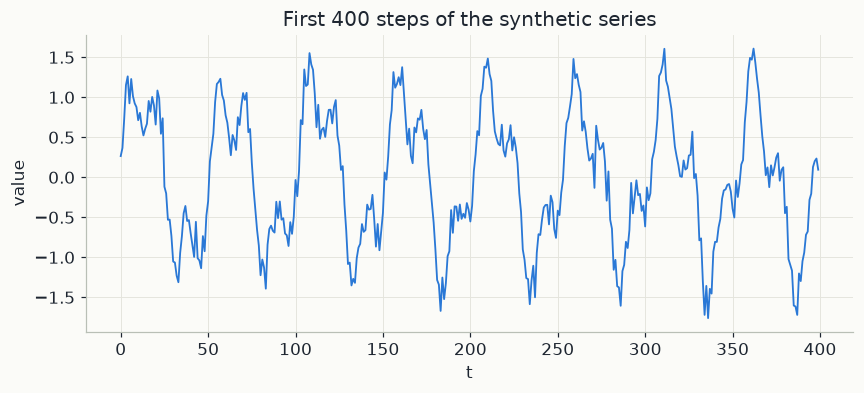

In [2]:
t = np.arange(0, 2000)
y = (np.sin(2*np.pi*t/50) + 0.5*np.sin(2*np.pi*t/17) + 0.02*np.sin(2*np.pi*t/400)
     + np.random.normal(0, 0.15, size=t.shape)).astype("float32")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t[:400], y[:400], color=mlutils.BLUE, lw=1.2)
ax.set(xlabel="t", ylabel="value", title="First 400 steps of the synthetic series")

## 6. Windowing: turning a sequence into (input, target) pairs

As in section 1, we slide a window of 30 past values across the series; the target
is the very next value. This is exactly the same
"honest windows, no peeking" idea as the Understanding Time Series course's chapter 04
— the window at time $t$ may only see values up to $t-1$.

In [3]:
window = 30
X_all = np.stack([y[i:i+window] for i in range(len(y) - window)])
y_all = y[window:]

n_train = int(0.8 * len(X_all))
X_train, X_test = X_all[:n_train], X_all[n_train:]
y_train, y_test = y_all[:n_train], y_all[n_train:]
print(f"train windows: {X_train.shape}, test windows: {X_test.shape}")

train windows: (1576, 30), test windows: (394, 30)


In [4]:
# scale using TRAINING statistics only, to avoid leaking test information
mu, sigma = X_train.mean(), X_train.std()
X_train_s = ((X_train - mu) / sigma)[..., np.newaxis]
X_test_s = ((X_test - mu) / sigma)[..., np.newaxis]
y_train_s = (y_train - mu) / sigma
y_test_s = (y_test - mu) / sigma

## 7. The model and a naive baseline

The naive baseline just predicts "the next value equals the last observed value" —
persistence. Any real model has to beat this to be worth its complexity.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window, 1)),
    tf.keras.layers.LSTM(24),
    tf.keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train_s, y_train_s, epochs=15, batch_size=32, validation_split=0.1, verbose=0)
print(f"final training loss: {history.history['loss'][-1]:.4f}, "
      f"validation loss: {history.history['val_loss'][-1]:.4f}")

final training loss: 0.0471, validation loss: 0.0423


In [6]:
pred_s = model.predict(X_test_s, verbose=0).flatten()
mse_lstm = float(np.mean((pred_s - y_test_s) ** 2)) * sigma**2       # back to original units

naive_pred = X_test[:, -1]                                            # "next = last observed"
mse_naive = float(np.mean((naive_pred - y_test) ** 2))

print(f"LSTM test MSE:              {mse_lstm:.4f}")
print(f"naive persistence test MSE: {mse_naive:.4f}")
print(f"LSTM is {mse_naive / mse_lstm:.2f}x better than the naive baseline")

LSTM test MSE:              0.0300
naive persistence test MSE: 0.0693
LSTM is 2.31x better than the naive baseline


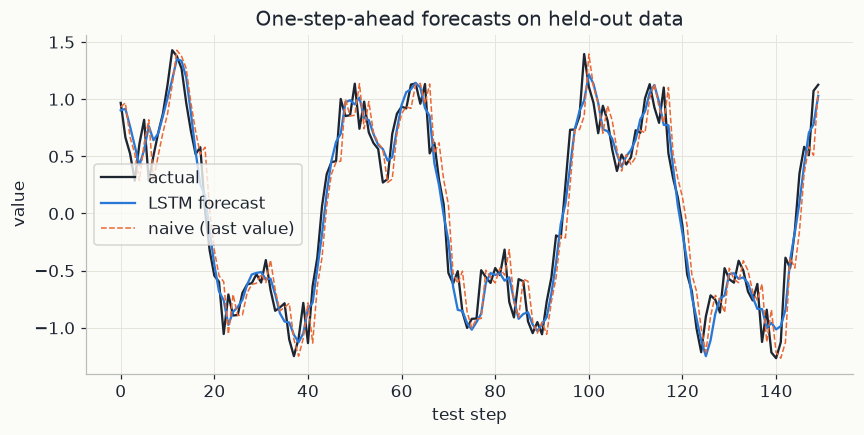

In [7]:
pred = pred_s * sigma + mu
fig, ax = plt.subplots(figsize=(9, 4))
show = 150
ax.plot(y_test[:show], color=mlutils.INK, lw=1.5, label="actual")
ax.plot(pred[:show], color=mlutils.BLUE, lw=1.5, label="LSTM forecast")
ax.plot(naive_pred[:show], color=mlutils.ORANGE, lw=1, ls="--", label="naive (last value)")
ax.set(xlabel="test step", ylabel="value", title="One-step-ahead forecasts on held-out data")
ax.legend()

The LSTM tracks the fast wiggle the naive baseline always lags by one step — it has
learned the short-period sine component well enough to anticipate the turn, not just
repeat the last value.

## Exercises

### Exercise 1: Window size
Retrain with `window = 5` and `window = 100`. Which does better on test MSE? What
does too short a window fail to capture here, given the periods used to build `y`?

<details><summary>Solution</summary>

A window of 5 is shorter than even the fastest period (17 steps) and can't see enough
of a cycle to extrapolate it; a much longer window (100) has enough context but takes
longer to train and doesn't necessarily help further once the relevant periods are
already covered.
</details>

### Exercise 2: SimpleRNN vs. LSTM
Swap `tf.keras.layers.LSTM(24)` for `tf.keras.layers.SimpleRNN(24)` and retrain. Does
test MSE change much on a sequence this short? At what point (longer sequences, more
history required) would you expect the LSTM's gating to start mattering more?

<details><summary>Solution</summary>

On a short window (30 steps) a SimpleRNN often performs comparably to the LSTM — the
vanishing-gradient problem LSTMs are designed to fix mainly bites on much longer
sequences, where a plain RNN struggles to keep information from many steps back.
</details>

## Key takeaways

- Windowing turns a single long sequence into supervised (input, target) pairs; the
  window may only look backward, never at data from after the target.
- An LSTM's gates let it learn what to carry forward and what to discard at each
  step, which is what makes it trainable on longer sequences than a plain RNN.
- Always compare against the naive "predict the last value" baseline — it's a
  surprisingly strong opponent, and the whole point of a model is to beat it.